In [105]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import sympy as smp
import scipy as scp
from scipy.interpolate import interp1d

In [106]:
class UAV:
    '''Класс летательного аппарата\n
    Параметры конструктора:\n
    mass - масса ЛА\n
    V - воздушная скорость\n
    CGposition - положение центра масс относительно передней кромки крыла в единицах средней хорды крыла\n
    WingData - кортеж, содержащий основные геомерические харакеристики крыла\n
        airfoil - строка названия файла с коэффициентами профиля крыла и точками срыва потока из XFOIL, 
        лежащего в одной дериктории с программой\n
        S - площадь крыла\n
        TaperRatio - сужение крыла\n
        AspectRatio - удлинение крыла\n
        RootChord - длина корневой хорды крыла\n
        AileronRatio - доля хорды крыла под элерон\n
        etai - расстояние от корневой хорды до начала управляющей поверхности в единицах полуразмаха\n
        etae - расстояние от корневой хорды до конца управляющей поверхности в единицах полуразмаха\n
        iw - угол установки крыла в градусах\n
    FusWidth - ширина фюзеляжа\n
    FusLength - длина фюзеляжа без учета хвостовой балки при наличии\n
    Tail - кортеж характеристик хвостового оперения\n
        Type - тип хвостового оперения\т
            "V" - V-образный\n
            "C" - традиционный\n
            "T" - T-образный\n
        Airfoil - строка названия файла с коэффициентами профиля хвоста и точками срыва потока из XFOIL\n
        HorizontalVolumeCoeff - горизонтальный объемный коэффициент\n
        VerticalVolumeCoeff - вертикальный объемный коэффициент\n
        TailArm - плечо хвостового оперение (расстояние от аэрод. центра хвоста до аэрод. центра крыла)\n
        etai - расстояние от корневой хорды до начала управляющей поверхности в единицах полуразмаха\n
        etae - расстояние от корневой хорды до конца управляющей поверхности в единицах полуразмаха\n
        iw - угол установки горизонтального оперения хвоста в градусах\n
    RootChrod - длина корневой хорды крыла. Если значение ненулевое, то оно используется при дальнейших расчетах геометрии крыла
    Иначе значение коренвой хорды вычисляется согласно данным из WingData по AspectRatio, TaperRatio и S\n
    SweepQuart - стреловидность крыла. Если true, то в функции отрисовки крыла и функциях подсчета коэффициентов используются стреловидное крыло,
    иначе по умолчанию рисуется крыло трапецевидное\n
    H - высота полета, по умолчанию 0
    '''
    __rho0 = 1.225
    rho = __rho0
    __g = 9.81
    __mu = 0.0289644
    __R = 8.3144598
    T = 273 + 15
    __visc = 18e-6 # вязкость
    def __init__(self, mass, V, CGposition, WingData, FusWidth, FusLength, Tail, cr=0, SweepQuart = True, H = 0):
        self.Va = V # воздушная скорость полета
        self.H = H # высота полета Относительно чего?
        self.__mass = mass # масса ЛА
        self.W = self.__mass * self.__g # Вес ЛА
        self.S = WingData[1] # Площадь крыла
        self.d = FusWidth # Ширина фюзеляжа в  
        self.L = FusLength # Длина фюзеляжа если хостовая балка есть, то ее в длину не влючаем
        self.FusS = 0.64 # Площадь поверхности фюзеляжа, подверженная обтеканию воздуха (Надо изменить) 

        self.__Ttype = Tail[0] # тип хвостового оперения 
        self.__Vht = Tail[2] # объемные коэффициенты хвостового оперения
        self.__Vvt = Tail[3]
        self.__Lt = Tail[4] # длина балки хвостового оперения (плечо хвоста) (между четвертями хорд)
        self.ART = 2 # Удлинение хвоствого оперения 
        self.TRT = 0.6 # сужение хвостового оперения

        self.__hac = 0.25 # расстояние от передней кромки крыла в ед САХ до аэродинамич центра 
        self.__hcg = CGposition # расстояние от передней кромки крыла в ед САХ до центра тяжести

        self.WingIncidenceAngle = WingData[-1]

        # Расчет размера крыла ###############################################
        if (cr == 0):
            self.AR = WingData[3]
            self.TR = WingData[2]
            self.c_mean = np.sqrt(self.S/self.AR)
            self.b = self.S/self.c_mean
            self.cr = self.S / (self.d + (1 + self.TR)*(self.b - self.d)/2)
            self.ct = self.cr * self.TR

        elif (cr != 0):
            self.AR = WingData[3]
            self.cr = WingData[4]
            self.c_mean = np.sqrt(self.S/self.AR)
            self.b = self.S/self.c_mean
            self.ct = 2*(self.S - self.cr*self.d)/(self.b - self.d) - self.cr
            self.TR = self.ct/self.cr
            if (self.TR >= 1):
                self.TR = 1
                self.c_mean = np.sqrt(self.S/self.AR)
                self.ct = self.c_mean
                self.cr = self.ct

        ex = np.array([1., 0])
        ey = np.array([0, 1.])
        if (SweepQuart == False):
            a = 3/4*self.cr * ex + ey * 0.5 * (self.b - self.d) + ex*1/4*self.ct - ex*self.cr
            b = 3/4*self.cr * ex + ey * 0.5 * (self.b - self.d) - ex * 3/4*self.ct
            e = b + ex*0.5*self.ct
    
            self.SweepLE = np.acos(np.dot(ey, a) / (norm(a) * norm(ey)))
            self.SweepTE = np.acos(np.dot(ey, b) / (norm(b) * norm(ey)))

            self.SweepHalf = np.acos(np.dot(ey, e - ex*0.5*self.cr) / (norm(e - ex*0.5*self.cr) * norm(ey)))
            self.SweepQuart = 0
        elif (SweepQuart == True):
            self.SweepLE = np.atan((self.cr - self.ct) / (self.b - self.d))
            self.SweepQuart = np.tan(self.SweepLE) + self.cr*0.5/(self.b - self.d) * (self.TR - 1)
            self.SweepHalf = 0

        self.__Swet = 2*self.S - 2 * (self.d * self.cr)

        # после подсчета всех основных геометрических харакеристик вычислим САХ
        # General Aviation p.328 (Есть разница для трапецевидного крыла средней хорды c и средней 
        # геометрической хорды САХ). Именно САХ используется для нормировки коэффициентов
        self.c = 2/3 * self.cr * ((self.TR)**2 + self.TR + 1)/ (self.TR + 1)
        #########################################################################################

        # Расчет размера хвоствого оперения #####################################################
        self.Sht = self.__Vht * self.c * self.S / self.__Lt
        self.Svt = self.__Vvt * self.b * self.S / self.__Lt
        if (self.__Ttype == 'V'):
            self.Stail = self.Sht + self.Svt
            self.DihedraTail = np.atan(self.Svt/self.Sht) # rad
        self.btail = np.sqrt(self.Stail / 2  * self.ART)
        self.ctail = self.btail / self.ART
        self.crtail = 2 * self.ctail / (1 + self.TRT)
        self.cttail = self.TRT * self.crtail

        self.SweepLEtail = np.atan((self.crtail - self.cttail) / self.btail)
        self.SweepQuarttail = np.atan( 3 * (self.crtail - self.cttail) / (4 * self.btail))
        self.SweepHalftail = np.atan( (-self.cttail + self.crtail) / (2 * self.btail) )

        self.__Swettail = self.Stail * 2 # Полная площадь поверхности хвостового оперения
        #########################################################################################

        # Оставил пока эту часть для обратной совместимости, но в дальнейшем надо пользоваться 
        # функцией GetAirfoilWingData
        self.airfoilW = WingData[0]
        if (self.GetReynolds('MeanW') <= 250000):
            self.airfoilWDat = np.loadtxt('{}.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        elif (self.GetReynolds('MeanW') > 250000 and self.GetReynolds('MeanW') <= 400000):
            self.airfoilWDat = np.loadtxt('{}_300.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        elif (self.GetReynolds('MeanW') > 400000 and self.GetReynolds('MeanW') <= 600000):
            self.airfoilWDat = np.loadtxt('{}_500.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        elif (self.GetReynolds('MeanW') > 500000 and self.GetReynolds('MeanW') <= 1000000):
            self.airfoilWDat = np.loadtxt('{}_1000.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        self.xtop = self.airfoilWDat[:, 5]
        self.xbot = self.airfoilWDat[:, 6]
        self.AOA = self.airfoilWDat[:, 0] - np.ones(len(self.airfoilWDat[:, 0]))*WingData[-1] 
        self.fxtop = interp1d(self.AOA, self.xtop) # интерполяционные функции для точки перехода
        self.fxbot = interp1d(self.AOA, self.xbot) # от ламинарного к турбулентному течению в зависимости от угла атаки

        self.airfoilWGeo = np.loadtxt('{}G.txt'.format(self.airfoilW), skiprows=1, dtype=float)
        self.thick = self.airfoilWGeo[0]
        self.thickLoc = self.airfoilWGeo[1]
        self.cam = self.airfoilWGeo[2]
        self.camLoc = self.airfoilWGeo[3]

        self.airfoilT = Tail[1] # Профиль хвостового оперения
        self.airfoilTDat = np.loadtxt('{}.txt'.format(self.airfoilT), skiprows = 11, dtype=float)
        self.xtopT = self.airfoilTDat[:, 5]
        self.xbotT = self.airfoilTDat[:, 6]
        self.AOAT = self.airfoilTDat[:, 0] - np.ones(len(self.airfoilTDat[:, 0]))*Tail[-1] * np.cos(self.DihedraTail)
        self.fxtopT = interp1d(self.AOAT, self.xtopT) # интерполяционные функции для точки перехода
        self.fxbotT = interp1d(self.AOAT, self.xbotT) # от ламинарного к турбулентному течению в зависимости от угла атаки

        self.airfoilTGeo = np.loadtxt('{}G.txt'.format(self.airfoilT), skiprows=1, dtype=float)
        self.thickT = self.airfoilTGeo[0]
        self.thickLocT = self.airfoilTGeo[1]
        self.camT = self.airfoilTGeo[2]
        self.camLocT = self.airfoilTGeo[3]

        self.__GetAirDensity(H)

        # Параметры управляющих поверхностей #############################################
        # TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)
        # WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)
        self.cfw = WingData[5] # доля хорды крыла на элероны
        self.cft = Tail[5] # доля хорды хвосового оперения на rudevator
        self.etai = WingData[6]
        self.etae = WingData[7]
        self.etaiT = Tail[6]
        self.etaeT = Tail[7]

        # Теоретический наклон кривой подъемного коэфф для профиля в зависимости от толщины
        thickness = [0, 0.6, 0.10, 0.14, 0.18, 0.2]
        clath = [6.3, 6.59, 6.79, 6.99, 7.19, 7.3]
        self.fClath = interp1d(thickness, clath)

        # Теоретическое значение dCl/ddelta
        thickness02 = [0, 0.04, 0.1, 0.15]
        thickness03 = [0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.15]
        cldth02 = [3.4, 3.55, 3.625, 3.75]
        cldth025 = [3.8, 3.875, 4.1, 4.25]
        cldth03 = [4.155, 4.229, 4.283, 4.352, 4.406, 4.465, 4.549, 4.609]
        
        self.Cldelta02 = interp1d(thickness02, cldth02)
        self.Cldelta025 = interp1d(thickness02, cldth025)
        self.Cldelta03 = interp1d(thickness03, cldth03)
        
        # Отношение реальной к теоретической dCl/ddelta
        Cldeltaratio02 = np.loadtxt('CldeltaRatio02.csv', skiprows=1, dtype=float, delimiter=',')[:, 3] + 0.3
        Cldeltaratio025 = np.loadtxt('CldeltaRatio025.csv', skiprows=1, dtype=float, delimiter=',')[:, 3] + 0.3
        Cldeltaratio03 = np.loadtxt('CldeltaRatio03.csv', skiprows=1, dtype=float, delimiter=',')[:, 3] + 0.3
        claRatio = np.linspace(0.7, 1, 16)

        self.CldeltaRatio02 = interp1d(claRatio, Cldeltaratio02)
        self.CldeltaRatio025 = interp1d(claRatio, Cldeltaratio025)
        self.CldeltaRatio03 = interp1d(claRatio, Cldeltaratio03)

        # Коэффициент отклонения рулей для профиля
        K02 = np.loadtxt('AirfoilFlapCoeff02.csv', dtype=float, delimiter=',', skiprows=1)[:,3]
        K025 = np.loadtxt('AirfoilFlapCoeff025.csv', dtype=float, delimiter=',', skiprows=1)[:,3]
        K03 = np.loadtxt('AirfoilFlapCoeff03.csv', dtype=float, delimiter=',', skiprows=1)[:,3]
        deflection = np.linspace(0, 40, 9)

        self.fK02 = interp1d(deflection, K02)
        self.fK025 = interp1d(deflection, K025)
        self.fK03 = interp1d(deflection, K03)

        # Коэффициент отклонения рулей для секции
        Kb = np.loadtxt('KbFlapTR05.csv', delimiter=',', dtype=float, skiprows=1)[:,3]
        eta = np.linspace(0, 1, 21)
        self.fKb = interp1d(eta, Kb)
        ##################################################################################

    def __GetAirDensity(self, h):
        self.rho = self.__rho0*np.exp(-self.__g * self.__mu * h / (self.__R * self.T))

    def GetLocalChord(self, y):
        '''Функция возращяет значение длины хорды крыла на расстоянии y от корневой хорды
        Функция справидлива для крыла любой трапецивидной формы (со стреловидностью и без)'''
        c_y = self.cr * (1 + 2*(self.TR - 1)*y/self.b)
        return c_y

    def GetReynolds(self, type, x = 0):
        '''Возвращае число Рейнольдса

        "MeanW" - для САХ,

        "RootW" - для корневой хорды,

        "TipW" - для концевой хорды,

        "LocalW" - для расстояния x от корневой хорды

        "Fus" - для фюзеляжа,  

        "RootT" - для корневой хорды хвоста,

        "TipT" - для концевой хорды хвоста,

        "MeanT" - для САХ хвоста

        Если число Рейнольдса превышает число Рейнольдса отрыва

        Recutoff = 38.21(c/k)**1.053

        (см. General Aviation Aircraft Design стр.682, формула (16-31))

        для поверхности c характерной норовностью k, то учитывается оно'''
        kcomp = 0.2e-5 * 0.3048 # Композит
        k3d = 20e-6 # для 3д принтера 20 мкм не обработаная поверхность перпендикулярон слоям
    
        if type == 'MeanW':
            Recoff = 38.21*(self.c/kcomp)**1.053
            R = self.rho * self.Va * self.c / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R 
            
        if type == 'RootW':
            Recoff = 38.21*(self.cr/kcomp)**1.053
            R = self.rho * self.Va * self.cr / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R
            
        if type == 'TipW':
            Recoff = 38.21*(self.ct/kcomp)**1.053
            R = self.rho * self.Va * self.ct / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R
            
        if type == 'Fus':
            Recoff = 38.21*(self.L/k3d)**1.053
            R = self.rho * self.Va * self.L / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R
        
        if type == 'LocalW':
            c_y = self.GetLocalChord(x)
            return self.rho * self.Va * c_y / self.__visc
        
        if type == 'RootT':
            Recoff = 38.21*(self.crtail/k3d)**1.053
            R = self.rho * self.Va * self.crtail / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R 
            
        if type == 'TipT':
            Recoff = 38.21*(self.cttail/k3d)**1.053
            R = self.rho * self.Va * self.cttail / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R 
            
        if type == 'MeanT':
            Recoff = 38.21*(self.ctail/k3d)**1.053
            R = self.rho * self.Va * self.ctail / self.__visc
            if R >= Recoff:
                return Recoff
            else:
                return R 
        
    def GetReynoldsSpanDistribution(self):
        '''Функция возращает кортеж (x, Re), где 
        x - массив координат от корневой хорды крыла от 0 до b/2
        Re - массив чисел Рейнольдса, соответствующие хорде крыла на расстоянии из x'''
        step = 0.005 # шаг по размаху крыла в метрах
        x = np.linspace(0, self.b/2, (int)((self.b/2) / step)+1)
        ReDistr = np.array([])
        for el in x:
            LocRe = self.GetReynolds(type="LocalW", x=el)
            ReDistr = np.append(ReDistr, LocRe)
        return (x, ReDistr)

    def GetAirfoilWingData(self, y):
        '''Функция возращает набор интерполяционных функция для параметров профиля крыла на расстоянии y от корневой хорды:
        коэфф. подъемной силы fCl, лобового сопротивления fCd, момента тангажа fCm, 
        точки перехода от ламинарного обтекания к турбулентному fxtopW и fxbotW. Все функции в зависимости
        от угла атаки (AOA, Cl(AOA), Cd(AOA), Cm(AOA), fxtopW(AOA), fxbotW(AOA))'''
        
        # Получим длину хорды на расстоянии y
        c_y = self.GetLocalChord(y)
        # Расчитаем число Рейнольдса для хорды на расстоянии c_y
        Re = self.GetReynolds(type="LocalW", x=y)
        # С учетом числа Рейнольдса выберем файл с нужными данными
        if (Re >= 25000 and Re < 75000):
            airfoilWDat = np.loadtxt('{}_50.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 75000 and Re < 125000):
            airfoilWDat = np.loadtxt('{}_100.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 125000 and Re < 175000):
            airfoilWDat = np.loadtxt('{}_150.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 175000 and Re < 225000):
            airfoilWDat = np.loadtxt('{}_200.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 225000 and Re < 275000):
            airfoilWDat = np.loadtxt('{}_250.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 275000 and Re < 325000):
            airfoilWDat = np.loadtxt('{}_300.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 325000 and Re < 375000):
            airfoilWDat = np.loadtxt('{}_350.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 375000 and Re < 425000):
            airfoilWDat = np.loadtxt('{}_400.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 425000 and Re < 475000):
            airfoilWDat = np.loadtxt('{}_450.txt'.format(self.airfoilW), skiprows = 11, dtype=float)
        if (Re >= 475000 and Re < 525000):
            airfoilWDat = np.loadtxt('{}_500.txt'.format(self.airfoilW), skiprows = 11, dtype=float)

        # угол атаки профиля в градусах
        AOA = airfoilWDat[:, 0]- np.ones(len(airfoilWDat[:, 0]))*self.WingIncidenceAngle
        # коэффициент подъемной силы
        Cl = airfoilWDat[:, 1]
        # Коэффицент лобового сопротивления
        Cd = airfoilWDat[:, 2]
        # Коэффициент момента тангажа
        Cm = airfoilWDat[:, 4]
        # точка перехода от ламинарного к турбулентному
        # для верхней и нижне частей
        xtopW =  airfoilWDat[:, 5]
        xbotW =  airfoilWDat[:, 6]

        # Интерполяционные функции для каждой из зависимостей
        return (AOA,
                interp1d(AOA, Cl), 
                interp1d(AOA, Cd), 
                interp1d(AOA, Cm), 
                interp1d(AOA, xtopW),
                interp1d(AOA, xbotW))

    def GetSkinFriction(self, type, side, AOA):
        '''Функция считает коэффициент силы трения в приближении
        турбулентного-ламинароного обтекания тела при угле атаки AOA в градусах
        
        'Fus' - для фюзеляжа,

        "MeanW" - для САХ,

        "RootW" - для корневой хорды,

        "TipW" - для концевой хорды,

        "RootT" - для корневой хорды хвоста,

        "TipT" - для концевой хорды хвоста,

        "MeanT" - для САХ хвоста
        '''
        # Нужно доделать так же и для хвоста, как и для крыла
        Re = self.GetReynolds(type)
        if (type[-1] == 'T'):
            if side == 'Top':
                x0 = 36.9*self.fxtopT(AOA * np.cos(self.DihedraTail))**0.625 * (1/Re)**0.375
                return 0.074/(Re**0.2) * (1 - (self.fxtopT(AOA* np.cos(self.DihedraTail)) - x0))**0.8
            elif side == 'Bottom':
                x0 = 36.9*self.fxbotT(AOA* np.cos(self.DihedraTail))**0.625 * (1/Re)**0.375
                return 0.074/(Re**0.2) * (1 - (self.fxbotT(AOA* np.cos(self.DihedraTail)) - x0))**0.8

        elif (type[-1] == 'W'):
            if side == 'Top':
                # функция распределния точки перехода от ламинарного к турбулентному от угла атаки
                # для верхней части профиля
                if (type == "RootW"):
                    fxt = self.GetAirfoilWingData(0)[4]
                elif (type == "MeanW"):
                    fxt = self.GetAirfoilWingData(self.c)[4]
                else:
                    fxt = self.GetAirfoilWingData(self.b/2)[4]
                x0 = 36.9 * fxt(AOA)**0.625 * (1/Re)**0.375
                return 0.074/(Re**0.2) * (1 - (fxt(AOA) - x0))**0.8
            elif side == 'Bottom':
                # функция распределния точки перехода от ламинарного к турбулентному от угла атаки
                # для нижней части профиля
                if (type == "RootW"):
                    fxb = self.GetAirfoilWingData(0)[5]
                elif (type == "MeanW"):
                    fxb = self.GetAirfoilWingData(self.c)[5]
                else:
                    fxb = self.GetAirfoilWingData(self.b/2)[5]
                x0 = 36.9 * fxb(AOA)**0.625 * (1/Re)**0.375
                return 0.074/(Re**0.2) * (1 - (fxb(AOA) - x0))**0.8
        else: # Для фюзеляжа взял оценку, что переход от ламинарного к турбулентному потоку происходит почти сразу
              # на рассоянии лишь 1% от общей длины фюзеляжа
            x0 = 36.9 * 0.01**0.625 * (1/Re)**0.375 
            return 0.074/(Re**0.2) * (1 - (0.01 - x0))**0.8

    def GetCDmin(self, crud = 1.25, AOA = 0, distr = False):
        '''Функция подсчитывает минимальный коэффициент лобового сопротивления для всего самолета
        на основе геометрических характеристик крыла, хвостового оперения и фюзеляжа'''
        # Сопротивление крыла #################
        Ctip = 0.5 * (self.GetSkinFriction(type='TipW', side='Top', AOA = AOA) + self.GetSkinFriction(type='TipW', side='Bottom', AOA = AOA))
        Croot = 0.5 * (self.GetSkinFriction(type='RootW', side='Top', AOA = AOA) + self.GetSkinFriction(type='RootW', side='Bottom', AOA = AOA))
        Cfw = 0.5 * (Croot + Ctip)
        Cdw = (self.__Swet / self.S) * Cfw

        # if (abs(self.thickLoc - 0.3) <=0.05):
        #     FFw = 1 + 2*(self.thick) + 60(self.thick)**4
        # elif (self.thickLoc >= 0.4 and self.thickLoc <= 0.5):
        #     FFw = 1 + 1.2*(self.thick) + 70(self.thick)**4
        FFw = (3.3*(self.thick) - 0.008*(self.thick)**2 + 27*(self.thick)**3)*(np.cos(self.SweepHalf))**2 + 1
        IFw = 1.05
        Cdw = FFw * Cdw * IFw
        #######################################

        # Сопротивление фюзеляжа ##############
        # f = self.L/2 * np.sqrt(4 / self.d**2) # Это формула для тел вращения, но если в поперечном сечении
        # не круг, то стоит использовать формулу ниже
        # f = self.L / np.sqrt(self.CrossFusS) # CrossFusS - площадь поперечного сечения фюзеляжа
        f = self.L / np.sqrt(self.d * (self.d))
        ReF = self.GetReynolds(type='Fus')
        IFf = 1.0
        if (ReF <= 1e5):
            Cdf = 1.328/(ReF)**0.5 * (1 + f**-1.5) + 0.11*f**-2
        elif (ReF > 1e5):
            FFf1 = 1 + 1.5*f**-1.5 + 7*f**-3
            FFf2 = 1 + 2.2*f**-1.5 + 3.8*f**-3
            
            FFf3 = 1 + 60*f**-3 + f/400 #This provides a good correlation for fineness ratios 
            #(f) above 6 as is typical for high-speed and military aircraft, but 
            #seems to overestimate drag for fineness ratios much below 5.

            FFf4 = 2.939 - 0.7666*f + 0.1328*f**2 - 0.01074*f**3 + 3.275e-4*f**4
            FFf5 = 1 + 2.2*f**-1.5 - 0.9*f**-3
            FFf6 = 0.9 + 5*f**-1.5 + f/400 # From Raymer

            if (f > 5): # Исключил выпадающее значение FFf3 при малых finess ratio
                FFf = np.mean([FFf1, FFf2, FFf3, FFf4, FFf5, FFf6])
            else:
                FFf = np.mean([FFf1, FFf2, FFf4, FFf5, FFf6])
            Cdf = self.GetSkinFriction(type='Fus', side = 'Top', AOA=AOA) * FFf * (self.FusS) / self.S * IFf
        #######################################

        # Сопротивление хвостового оперения ##################
        Ctiptail = 0.5 * (self.GetSkinFriction(type='TipT', side='Top', AOA = AOA) + self.GetSkinFriction(type='TipT', side='Bottom', AOA = AOA))
        Croottail = 0.5 * (self.GetSkinFriction(type='RootT', side='Top', AOA = AOA) + self.GetSkinFriction(type='RootT', side='Bottom', AOA = AOA))
        Cft = 0.5 * (Croottail + Ctiptail)
        Cdt = self.__Swettail / self.S * Cft
        FFt = (3.3*(self.thickT) - 0.008*(self.thickT)**2 + 27*(self.thickT)**3)*(np.cos(self.SweepHalftail))**2 + 1
        IFt = 1.03
        Cdt = IFt * Cdt * FFt
        ######################################################
        if (distr == False):
            return (Cdf + Cdw + Cdt)*crud
        else:
            return (Cdf*crud, Cdw*crud, Cdt*crud)

    def GetAirfoilCl(self, AOA, type):
        '''Возвращает значение коэффициента подъемной
        силы профиля для заданного угла атаки
        type = "Wing" - для профиля крыла
        type = "Tail" - для профиля хвоста'''
        if (type == "Wing"):
            alpha = self.AOA
            Cl = self.airfoilWDat[:, 1]
            fCl = interp1d(alpha, Cl)
            return fCl(AOA)
        elif (type == "Tail"):
            alpha = self.AOAT
            Cl = self.airfoilTDat[:, 1]
            fCl = interp1d(alpha, Cl)
            return fCl(AOA * np.cos(self.DihedraTail))
    
    def GetAirfoilCd(self, AOA, type):
        '''Возвращает значение коэффициента силы 
        лобового сопротивления профиля для заданного угла атаки
        type = "Wing" - для профиля крыла
        type = "Tail" - для профиля хвоста'''
        if (type == "Wing"):
            alpha = self.AOA
            Cd = self.airfoilWDat[:, 2]
            fCd = interp1d(alpha, Cd)
            return fCd(AOA)
        elif (type == "Tail"):
            alpha = self.AOAT
            Cd = self.airfoilTDat[:, 2]
            fCd = interp1d(alpha, Cd)
            return fCd(AOA * np.cos(self.DihedraTail))
    
    def GetAirfoilCd0(self, type):
        '''Возвращает значение коэффициента силы 
        лобового сопротивления профиля для 0 угла атаки
        type = "Wing" - для профиля крыла
        type = "Tail" - для профиля хвоста'''
        if (type == "Wing"):
            alpha = self.AOA
            Cd = self.airfoilWDat[:, 2]
            fCd = interp1d(alpha, Cd)
            return fCd(0)
        elif (type == "Tail"):
            alpha = self.AOAT
            Cd = self.airfoilTDat[:, 2]
            fCd = interp1d(alpha, Cd)
            return fCd(0)
    
    def GetAirfoilCdmin(self, type):
        '''Функция возвращает значение минимального коэффициента лобового
        сопротивления и угла атаки, при котором это достигается для профиля

        type = 'Wing' - для профиля крыла

        type = 'Tail' - для профиля хвостового оперения'''
        cur = 10
        a = 0
        if (type == "Wing"):
            alpha = self.AOA
            Cd = self.airfoilWDat[:, 2]
            fCd = interp1d(alpha, Cd)
            for el in np.linspace(-5, 10, 10000):
                if (fCd(el) < cur):
                    cur = fCd(el)
                    a = el
            return (a, cur)
        elif (type == "Tail"):
            alpha = self.AOAT
            Cd = self.airfoilTDat[:, 2]
            fCd = interp1d(alpha, Cd)
            for el in np.linspace(-5, 10, 10000):
                if (fCd(el) < cur):
                    cur = fCd(el)
                    a = el
            return (a / self.DihedraTail, cur)
    
    def GetAirfoilCm(self, AOA, type, x = 0):
        '''Функция возращает значение коэффициента момента тангажа для выбранного угла атаки
        и расстояния x от корневой хорды'''
        # Получим интерполяционную функцию для коэфф. момента тангажа профиля
        fCm = self.GetAirfoilWingData(x)[3] 
        if (type == "Wing"):
            return fCm(AOA)
        elif (type == "Tail"):
            alpha = self.AOAT
            Cm = self.airfoilTDat[:, 4]
            fCm = interp1d(alpha, Cm)
            return fCm(AOA * np.cos(self.DihedraTail))
    
    def GetAirfoilClmax(self, type):
        curr = 0
        a=0
        if (type == "Wing"):
            alpha = self.AOA
            Cl = self.airfoilWDat[:, 1]
            fCl = interp1d(alpha, Cl)
            for el in np.linspace(0, alpha[-1], 10000):
                if fCl(el) >= curr:
                    curr = fCl(el)
                    a = el
            return (a, curr)
        if (type == "Tail"):
            alpha = self.AOAT
            Cl = self.airfoilTDat[:, 1]
            fCl = interp1d(alpha, Cl)
            for el in np.linspace(0, alpha[-1], 10000):
                if fCl(el) >= curr:
                    curr = fCl(el)
                    a = el
            return (a / self.DihedraTail, curr)
    
    def GetAirfoilClslope(self, AOA, type):
        '''Возвращает наклон кривой подъеного коэффициента
        профиля в 1/рад'''
        if (type == "Wing"):
            alpha = self.AOA
            Cl = self.airfoilWDat[:, 1]
            fCl = interp1d(alpha, Cl)
            return (-fCl(AOA) + fCl(AOA + 0.1))/0.1 *180/np.pi
        elif (type == "Tail"):
            alpha = self.AOAT
            Cl = self.airfoilTDat[:, 1]
            fCl = interp1d(alpha, Cl)
            return (-fCl(AOA * self.DihedraTail) + fCl(AOA * self.DihedraTail + 0.1))/0.1 *180/np.pi
        
    def GetAirfoilCl0(self, type):
        '''Возвращает коэффициент подъемной силы профиля
        при нулевом угле атаки'''
        if (type == 'Wing'):
            alpha = self.AOA
            Cl = self.airfoilWDat[:, 1]
            fCl = interp1d(alpha, Cl)
            return fCl(0)
        elif (type == 'Tail'):
            alpha = self.AOAT
            Cl = self.airfoilTDat[:, 1]
            fCl = interp1d(alpha, Cl)
            return fCl(0)
    
    def GetCLmax(self):
        '''Возвращает максимально достижимый коэффициент подъемной силы
        для крыла заданных размеров'''
        return 0.9 * np.cos(self.SweepQuart) * self.GetAirfoilClmax(type='Wing')[1]

    def GetCL0(self, type):
         az = (-1)*self.GetAirfoilCl0(type=type)/self.GetAirfoilClslope(AOA=0, type=type)
         return abs(az)*self.GetCLslope(type)

    def GetZeroLiftAOA(self):
        return (-1)*self.GetAirfoilCl0(type="Wing")/self.GetAirfoilClslope(AOA=0, type="Wing")
    
    def GetCLcruise(self):
        return self.GetCL0('Wing') + self.W/(self.GetDynamicPressure() * self.S) + self.GetCLslope('Wing')*self.GetZeroLiftAOA()
    
    def GetDynamicPressure(self):
        self.__GetAirDensity(self.H)
        if self.Va != 0:
            return self.rho * self.Va**2 / 2
        else:
            return self.rho * self.GetCruiseSpeed()**2 / 2
    
    def GetSpeedSound(self):
        return np.sqrt(1.4 * self.__R * self.T/self.__mu)
    
    def GetCLslope(self, type, AOA=0):
        """Расчитывает наклон кривой коэффициента подъемной силы
        для секции крыла в 1/rad"""
        if (type == 'Wing'):
            beta = 1 - (self.Va/self.GetSpeedSound())**2 # В формулах из книг - это beta**2
            k = self.GetAirfoilClslope(AOA=AOA, type=type) / (2*np.pi)
            x = self.AR/k * (beta + np.tan(self.SweepHalf)**2)**0.5
            eta = 0.98
            return 2*np.pi*self.AR / (2 + np.sqrt(x**2 + 4))*eta
        elif (type == 'Tail'):
            beta = 1 - (self.Va/self.GetSpeedSound())**2
            k = self.GetAirfoilClslope(AOA=AOA, type=type) / (2*np.pi)
            x = self.ART/k * (beta + np.tan(self.SweepHalftail)**2)**0.5
            eta = 0.98
            return 2*np.pi*self.ART / (2 + np.sqrt(x**2 + 4))*eta
    
    def GetOsvald(self, type, method = 'A'):
        if (type == 'Wing'):
            if (method == 'A'):
                return 2 / (2 - self.AR + np.sqrt(4 + self.AR**2*(1 + np.tan(self.SweepQuart))))
            if (method == 'B'):
                r = 0.38 - self.SweepLE * 57.3/3000 + (self.SweepLE * 57.3)**2/15000
                u = 0.98
                t = self.d / self.b
                CDmin = self.GetCDmin()
                return 1 / (np.pi*self.AR*r*CDmin + 1 / ((1 + 0.03*t - 2*t**2)*u))
        
        elif (type == 'Tail'):
            if (method == 'A'):
                return 2 / (2 - self.ART + np.sqrt(4 + self.ART**2*(1 + np.tan(self.SweepQuarttail))))
            if (method == 'B'):
                r = 0.38 - self.SweepLEtail * 57.3/3000 + (self.SweepLEtail * 57.3)**2/15000
                u = 0.98
                t = self.d / self.b
                CDmin = self.GetCDmin()
                return 1 / (np.pi*self.ART*r*CDmin + 1 / ((1 + 0.03*t - 2*t**2)*u))
            
    def GetTotalLiftCoefficient(self, AOA, deflecW, deflecT, distr = 'All'):
        CLw = self.GetCL0("Wing") + self.GetCLslope('Wing') * AOA/57.3
        CLdeltaw = self.GetCLdelta('Wing', deflecW)
        CLt = (self.GetCL0("Tail") + self.GetCLslope('Tail') * AOA/57.3) 
        # Нужно ли домножать на 2? Так как геомерические характеристики задаются для одной лопатки хвостового оперения,
        # то, вероятно, надо домножить на 2, но это не влияет на балансировочные кривые. Хотя При вычислении суммарного
        # кофф подъемной силы, учитываем двойную площадь хвостового оперения self.Sht
        CLdeltat = self.GetCLdelta('Tail', deflecT)

        CLtotal = CLw + CLdeltaw + self.Sht / self.S * (CLt + CLdeltat) * np.cos(self.DihedraTail) # Брать отношение горизонтальной площади или всего хвоста?
        if (distr == "Wing"):
            return (CLw)
        if (distr == "Tail"):
            return CLt
        else:
            return CLtotal
    
    def GetCLmaxTotal(self):
        CLmw = self.GetCLmax()
        CLmt = 0.9 * np.cos(self.SweepQuarttail) * self.GetAirfoilClmax(type='Tail')[1] * self.Sht / self.S * np.cos(self.DihedraTail)
        return CLmw + CLmt
    
    def GetStallSpeed(self):
        CLm = self.GetCLmaxTotal()
        return np.sqrt(2*self.W / (self.rho * self.S * CLm))
    
    def GetAirfoilCldelta(self, type, deflec):
        '''Функция принимает тип (type) поверхности, для которой необходимо
        расчитать производную коэфф подъемной силы профиля по отклонению рулей
        при заданном отклонении рулей на угол deflec. Положительный 
        соответствует отколонению рулей вниз
        
        type = 'Wing' - для крыла,
        
        type = 'Tail' - для хвостового оперения'''
        if (type == 'Wing'):
            Clatheory = self.fClath(self.thick)
            # claRatio = self.GetAirfoilClslope(AOA=AOA, type=type) / Clatheory
            claRatio = 0.85
            if (claRatio >1):
                claRatio = 1
            if (claRatio < 0.7):
                claRatio = 0.7

            if (abs(self.cfw - 0.2) < 0.025):
                CldeltaRatio = self.CldeltaRatio02(claRatio)
                Cldeltath = self.Cldelta02(self.thick)
                K = self.fK02(abs(deflec))
            elif (abs(self.cfw - 0.25) < 0.025):
                CldeltaRatio = self.CldeltaRatio025(claRatio)
                Cldeltath = self.Cldelta025(self.thick)
                K = self.fK025(abs(deflec))
            elif (abs(self.cfw - 0.3) < 0.025):
                CldeltaRatio = self.CldeltaRatio03(claRatio)
                Cldeltath = self.Cldelta03(self.thick)
                K = self.fK03(abs(deflec))
            return CldeltaRatio * Cldeltath * K * deflec/57.3
       
            
        elif (type == 'Tail'):
            Clatheory = self.fClath(self.thickT)
            # claRatio = self.GetAirfoilClslope(AOA=AOA, type=type) / Clatheory # из-за нелинейности профиля дает сбои
            # заменил на данные из DATCOM для отношения коэфф. подъемной силы профиля
            claRatio = 0.85
            if (claRatio > 1):
                claRatio = 1

            if (abs(self.cft - 0.2) < 0.025):
                CldeltaRatio = self.CldeltaRatio02(claRatio)
                Cldeltath = self.Cldelta02(self.thickT)
                K = self.fK02(abs(deflec))
            elif (abs(self.cft - 0.25) < 0.025):
                CldeltaRatio = self.CldeltaRatio025(claRatio)
                Cldeltath = self.Cldelta025(self.thickT)
                K = self.fK025(abs(deflec))
            elif (abs(self.cft - 0.3) < 0.025):
                CldeltaRatio = self.CldeltaRatio03(claRatio)
                Cldeltath = self.Cldelta03(self.thickT)
                K = self.fK03(abs(deflec))
            return CldeltaRatio * Cldeltath * K * deflec/57.3
            
    def GetCLdelta(self, type, deflec):
        deltaCldelta = self.GetAirfoilCldelta(type = type, deflec=deflec)
        a = 1.05
        b = self.GetCLslope(type) / self.GetAirfoilClslope(type=type, AOA=0)
        if (type == 'Tail'):
            Kb = self.fKb(self.etaeT) - self.fKb(self.etaiT)
            return deltaCldelta * a * b * Kb * np.cos(self.DihedraTail)
        else:
            Kb = self.fKb(self.etae) - self.fKb(self.etai)
            return deltaCldelta * a * b * Kb
        
    def GetTotalDragCoefficient(self, AOA, deflec, distr = "All"):
        if (distr == "Wing"):
            CD0 = self.GetCDmin(distr=True)[1]
            CDi = (self.GetTotalLiftCoefficient(AOA, deflecW=0, deflecT=0, distr="Wing"))**2 / (self.AR * self.GetOsvald(type='Wing', method='B') * np.pi)
            return (CD0,CDi)
        
        CD0 = self.GetCDmin()
        CDi = (self.GetTotalLiftCoefficient(AOA, deflecW=0, deflecT=0))**2 / (self.AR * self.GetOsvald(type='Wing', method='B') * np.pi)
        CDd = 0.0006 * abs(deflec) # Взял из оценок из General Aviation. По модулю отклонение рулей, так как отрицательным коэфф.
        # лобового оспроивления быть не может
        return (CD0 + CDi + CDd)

    def GetCm(self, AOA, deflec, distr = False):
        '''Функция подсчитывает коэффициент момента тангажа'''
        # Крыло #######################
        # DATCOM 4.1.4.1-b
        Cm0w = (self.GetAirfoilCm(AOA, type='Wing', x = 0)+ self.GetAirfoilCm(AOA, type="Wing", x=self.b/2))/2 * ( (self.AR * np.cos(self.SweepQuart)**2) / (self.AR + 2*np.cos(self.SweepQuart)) )
        Cm0w += self.GetCL0('Wing')*(self.__hcg - self.__hac)
        Cmalphaw = self.GetCLslope('Wing', AOA) * (self.__hcg - self.__hac)
        #####################################

        # Хвост ###############################
        Cm0t = self.GetAirfoilCm(AOA=0, type='Tail') * ( (self.ART * np.cos(self.SweepQuarttail)**2) / (self.ART + 2*np.cos(self.SweepQuarttail)) ) #* (self.Sht / self.S) * (self.ctail / self.c)
        # Нужно ли брать коэфф. момента тангажа, как профиля, или нормировать на площади хвостового оперения?
        # На балансировочные кривые не влияет наличие или отсутствие последних двух множителей
        Ltcg = self.__Lt / self.c + 0.25 - self.__hcg # Плечо хвостового оперения от четверти хорды хвоста до центра тяжести 
        Cm0t += self.GetCL0('Tail') * (Ltcg) * (self.Sht / self.S)

        eta = 0.9 # Ослабление динамического давления у хвоста
        dEdalpha = 0.1 #2 * self.GetCLslope('Wing', AOA) / (np.pi * self.AR) # отклонение потока крылом в области у хвостового оперения
        Cmalphat = -eta * self.Sht / self.S * Ltcg * self.GetCLslope('Tail', AOA)*(1 - dEdalpha)
        if (deflec == 0):
            Cmdelatt = 0
        else:
            Cmdelatt = -self.GetCLdelta('Tail', deflec) / (deflec/57.3) * eta * self.Sht / self.S * Ltcg
        ########################################

        # Пропеллер ############################
        thrust = (self.GetTotalDragCoefficient(AOA = AOA, deflec=deflec) * np.cos(AOA/57.3) - self.GetTotalLiftCoefficient(AOA, deflecW=0, deflecT=deflec)*np.sin(AOA/57.3)) * self.GetDynamicPressure() * self.S
        #if (abs(AOA) <= 2): 
            #print(thrust) # просто вывожу, посмотреть, какая тяга нажна на малых углах атаки
        if (thrust < 0):
            thrust = 0
        Zprop = 0.04 # Расстояние по вертикали от линии действия тяги до центра масс
        Cm0prop = (-1)*thrust * Zprop / (self.GetDynamicPressure() * self.S * self.c)
        ########################################
        if (distr == True):
            return (Cm0w+Cmalphaw* (AOA/57.3), Cm0t+Cmalphat* (AOA/57.3), Cm0prop)
        else:
            return Cm0w + Cm0t + Cm0prop + (Cmalphaw + Cmalphat) * (AOA/57.3) + Cmdelatt * (deflec / 57.3)

    def GetNeutralPoint(self, AOA):
        '''Функция возвращает положение центра давления в единицах САХ крыла'''
        Ltcg = self.__Lt / self.c + 0.25 - self.__hcg
        return self.__hac + 0.9 * self.Sht / self.S * Ltcg * self.GetCLslope('Tail', AOA) / self.GetCLslope('Wing', AOA) * (1 - 0.1)

    def PlotWing(self):
        '''Функция рисует крыло с условными 
        обозначениями центра масс, центра давления и аэродинамического центра'''
        fig, ax = plt.subplots(1,1, figsize = ((210-45)/25.4,6))
        ax.set_xlim(-self.b/2*1.1, self.b/2*1.1 +0.35)
        ax.set_ylim(-0.01*self.cr, 1.*self.cr)
        ax.set_aspect('equal')
        ax.hlines(0, 0, self.d/2, color = 'black')
        ax.hlines(self.cr, 0, self.d/2, color='black')
        ax.vlines(self.d/2, 0, self.cr, color = 'black', linestyles='--')
        ax.plot([self.d/2, self.b/2,], [0, self.cr/2 - self.ct/2], color = 'black')
        ax.plot([self.d/2, self.b/2,], [self.cr, self.cr/2 + self.ct/2], color='black')
        ax.vlines(self.b/2, self.cr/2 - self.ct/2, self.cr/2 + self.ct/2, color = 'black')
        ax.hlines(0, 0, -self.d/2, color = 'black')
        ax.hlines(self.cr, 0, -self.d/2, color='black')
        ax.vlines(-self.d/2, 0, self.cr, color = 'black', linestyles='--')
        ax.plot([-self.d/2, -self.b/2,], [0, self.cr/2 - self.ct/2], color = 'black')
        ax.plot([-self.d/2, -self.b/2,], [self.cr, self.cr/2 + self.ct/2], color='black')
        ax.vlines(-self.b/2, self.cr/2 - self.ct/2, self.cr/2 + self.ct/2, color = 'black')

        hnp = self.GetNeutralPoint(AOA=0)*self.c
        ax.scatter(0, hnp, c='y', s = 5, label='ЦД={}'.format(round(hnp, 3)))
        ax.scatter(0, self.__hcg * self.c, s = 5, c = 'black', label = 'ЦМ={}'.format(round(self.__hcg * self.c, 3)))
        ax.scatter(0, self.c * self.__hac, c = 'r', s = 5, label='АЦ={}'.format(round(self.c * self.__hac, 3)))
        ax.legend(loc='upper right', fontsize=7)
        ax.set_axis_off()
        ax.text(-0.18, -0.05, 'Передняя кромка', size=7)
        # plt.savefig('Wing.png', dpi=300, bbox_inches='tight', pad_inches=0.01)

    def PlotVn(self, n_up, n_down):
        '''Функция отрисовывает V-n диаграмму согласно 
        Авиационным правилам часть 25. Зеленой областью
        отмечена рабочий диапазон перегрузок и скоростей'''
        figv, axv = plt.subplots(1,1, figsize=((210-45)/25.4,3.5))
        axv.spines['left'].set_position('zero')
        axv.spines['right'].set_color('none')
        axv.spines['bottom'].set_position('zero')
        axv.spines['top'].set_color('none')
        Vcruise = self.Va
        CLmax = self.GetCLmaxTotal() # бех механизации
        CLmax_mech = self.GetTotalLiftCoefficient(AOA=12, deflecT=20, deflecW=20) # макс коэф под силы с выпущенными элеронами
        # CLmin = self.GetCLminTotal()
        CLmin = -0.5
        Vdive = 1.4*Vcruise
        axv.vlines(Vdive, n_down, n_up, color='black')
        axv.hlines(0, 0, Vdive, linewidth = 1, color='black')
        Vstall_no_mech_up = np.sqrt( 2 * self.W / (self.rho * self.S * CLmax)) # скорость сваливания с убранными закрылками
        Vstall_no_mech_down = np.sqrt( 2 * self.W / (self.rho * self.S * abs(CLmin)))
        print(Vstall_no_mech_down) # скорость сваливания с убранными закрылками
        VA = np.sqrt(n_up) * Vstall_no_mech_up # Скорость маневренная, не меньше этого согласно АП25
        axv.hlines(n_up, 0, Vdive, linestyles='--', color = 'black', linewidth=1)
        axv.hlines(n_down, 0, Vdive, linestyles='--', color = 'black', linewidth=1)
        axv.vlines(Vcruise, 0, n_up, linestyles='--', color='black', linewidth=1)
        V = np.linspace(0, Vdive, 1000)

        # Вепхняя линия без механиз ########################################################################
        for i in range(1000):
            if (abs(V[i]**2*CLmax*self.S/self.W - n_up) <= 0.01):
                end_up= i
            if (abs((V[i]**2 - Vstall_no_mech_up**2) *CLmax*self.S/self.W) <= 0.01):
                start_up = i

        axv.plot(V[start_up:end_up], V[start_up:end_up]**2*CLmax*self.S/self.W, color = 'black')
        axv.plot(V[0:start_up], V[0:start_up]**2*CLmax*self.S/self.W, '--',color = 'black', linewidth=1)
        if (VA >= V[end_up]):
            VA = V[end_up]
            # axv.scatter(VA, n_up, c='red', s=7)
            axv.vlines(VA, 0, n_up, color='black', linestyles='--',linewidth=1)
        else:
            # axv.scatter(VA, VA**2*CLmax*self.S/self.W, c='red', s=7)
            axv.vlines(VA, 0, VA**2*CLmax*self.S/self.W, color='black', linestyles='--',linewidth=1)

        axv.vlines(Vstall_no_mech_up, 0, Vstall_no_mech_up**2*CLmax*self.S/self.W, color='black')
        #########################################################################################

        # Верхняя линия с мех ##################################################################
        for i in range(1000):
            if (abs(V[i]**2*CLmax_mech*self.S/self.W - n_up) <= 0.01):
                end_up_mech= i
            if (abs((V[i]**2 - Vstall_no_mech_up**2) *CLmax_mech*self.S/self.W) <= 0.01):
                start_up_mech = i
        axv.plot(V[0:end_up_mech], V[0:end_up_mech]**2*CLmax_mech*self.S/self.W, '-.', color='black')

        # Нижняя линия ##########################################################################
        for i in range(1000):
            if (abs(V[i]**2*CLmin*self.S/self.W - n_down) <= 0.01):
                end_down= i
            # if (abs((V[i]**2 - Vstall_no_mech_down**2) *CLmin*self.S/self.W) <= 0.01):
            #     start_down = i

        axv.plot(V[0:end_down], V[0:end_down]**2*CLmin*self.S/self.W, color = 'black')
        # axv.plot(V[0:start_down], V[0:start_down]**2*CLmin*self.S/self.W, '--',color = 'black')
        #########################################################################################

        axv.set_xticks(ticks=[Vstall_no_mech_up, VA, Vcruise, Vdive], labels=[r'$V_{s}$'+'={}'.format(round(Vstall_no_mech_up,1)), r'$V_{A}=$'+'{}'.format(round(VA,1)), r'$V_{C}=$'+'{}'.format(round(Vcruise,1)), r'$V_{D}=$'+'{}'.format(round(Vdive,1))])
        axv.hlines(n_up, V[end_up], Vdive, color='black')
        axv.hlines(n_down, V[end_down], Vdive, color='black')
        axv.set_xlim(0, Vdive+0.1)
        axv.set_ylim(n_down-0.1, n_up+0.2)
        axv.text(2.5, 2.5, 'опущенные элероны')
        axv.fill([Vstall_no_mech_up,Vstall_no_mech_up, VA, Vdive, Vdive, Vstall_no_mech_down, Vstall_no_mech_down], [0, Vstall_no_mech_up**2*CLmax*self.S/self.W, VA**2*CLmax*self.S/self.W, n_up, n_down, n_down, 0], color='green', alpha=0.6)
        # plt.savefig('Vn.png', dpi=300, bbox_inches = 'tight', pad_inches=0.01)

    def GetParameters(self):
        '''Функция выводит геометрические характеристики
        крыла и хвостового оперения'''
        print('Крыло #############################')
        print('Sw = {}'.format(round(self.S, 3)))
        print('bw = {}'.format(round(self.b, 3)))
        print('cw = {}'.format(round(self.c, 3)))
        print('crw = {}'.format(round(self.cr, 3)))
        print('AR = {}'.format(round(self.AR, 3)))
        print('TR = {}'.format(round(self.TR, 3)))
        print('iw = {}'.format(round(WingData[-1], 3)))
        print('###################################' + '\n')

        print('Хвостовое оперение #################')
        print('St = {}'.format(round(self.Stail, 3)))
        print('bt = {}'.format(round(self.btail, 3)))
        print('ct = {}'.format(round(self.ctail, 3)))
        print('crt = {}'.format(round(self.crtail, 3)))
        print('ctt = {}'.format(round(self.cttail, 3)))
        print('ARt = {}'.format(round(self.ART, 3)))
        print('TRt = {}'.format(round(self.TRT, 3)))
        print(r'$\gamma=$'+'{}'.format(round(self.DihedraTail*57.3, 0)))
        print('it = {}'.format(round(TailData[-1], 3)))
        print('Lt = {}'.format(round(self.__Lt, 3)))
        print('###################################' + '\n')

    def PlotPowerCurves(self):
        '''Функция рисует зависимость располагаемой и потребной тяги'''


In [107]:
S = 0.346
WingAirfoil = "SD7032"
TR = 0.75
AR = 8.
cr = 0.236
cf = 0.3
iw = 1.8 # угол установки крыла
etai = 0.5 # координата начала элеронов в ед полуразмаха
etae = 1 # координата конца элеронов в ед полуразмаха
WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

type = 'V'
TailAirfoil = 'NACA0008_300'
Vht = 0.6
Vvt = 0.04
Lt = 0.8
itail = 0 # Угол установки хвостового оперения
cf = 0.3
etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)

hcg = 0.4 # координата ценра масс от передней кромки в ед хорды

p = UAV(3.5, 18, hcg, WingData, 0.25, 1, TailData, cr = 0.236, SweepQuart=False)
p.GetParameters(), p.GetCDmin(), p.GetTotalDragCoefficient(0, 0), p.GetStallSpeed()

Крыло #############################
Sw = 0.346
bw = 1.664
cw = 0.205
crw = 0.236
AR = 8.0
TR = 0.72
iw = 1.8
###################################

Хвостовое оперение #################
St = 0.082
bt = 0.286
ct = 0.143
crt = 0.179
ctt = 0.107
ARt = 2
TRt = 0.6
$\gamma=$28.0
it = 0
Lt = 0.8
###################################



(None,
 np.float64(0.02668940646159636),
 np.float64(0.03964812870797504),
 np.float64(10.69223828052412))

Сравнение сопротивления при разных расположениях грузов

Text(0.5, 1.0, 'Зависимость коэффициента сопротивления от \n относительного удлинения фюзеляжа')

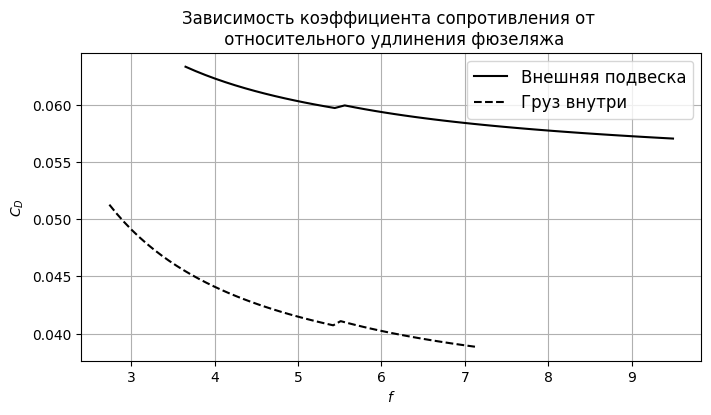

In [108]:
S = 0.35
WingAirfoil = "SD7032"
TR = 0.75
AR = 8.
cr = 0.236
cf = 0.3
iw = 1.8 # угол установки крыла
etai = 0.5 # координата начала элеронов в ед полуразмаха
etae = 1 # координата конца элеронов в ед полуразмаха
WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

type = 'V'
TailAirfoil = 'NACA0008_300'
Vht = 0.6
Vvt = 0.04
Lt = 0.8
itail = 0 # Угол установки хвостового оперения
cf = 0.3
etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)

Cd_payload = 2*0.8 * (0.07**2)/p.S # из численных расчтов коэффициента сопротивления в flow vision

Lf = np.linspace(0.5, 1.3, 50)
Cdf_tall = []
Cdf_small = []
d = [0.15, 0.2] # максимальная ширина фюзеляжа
for el in Lf:
    p = UAV(3.5, 18, hcg, WingData, d[1], el, TailData, cr = 0.236, SweepQuart=False)
    p.FusS = 0.74
    Cdf_tall.append(p.GetTotalDragCoefficient(0,0))
for el in Lf:
    p = UAV(3.5, 18, hcg, WingData, d[0], el, TailData, cr = 0.236, SweepQuart=False)
    p.FusS = 0.53
    Cdf_small.append(p.GetTotalDragCoefficient(0,0) + Cd_payload)
plt.figure(figsize=(8,4))
plt.plot(Lf/np.sqrt(d[0]*d[0]/1.2), Cdf_small, color = "black", linestyle = '-', label = r"Внешняя подвеска")
plt.plot(Lf/np.sqrt(d[1]*d[1]/1.2), Cdf_tall, color = "black", linestyle = '--', label = r"Груз внутри")
plt.grid("Major")
#plt.xlim(2.5, 7.5)
#plt.ylim(0.032, 0.039)
plt.xlabel(r"$f$")
plt.ylabel(r"$C_{D}$")
plt.legend(fontsize=12)
plt.title("Зависимость коэффициента сопротивления от \n относительного удлинения фюзеляжа")

Исследование формы крыла одной и той же площади ($TR \neq const, AR = const$) на аэродинамические коэффициенты. Рассматривалось крыло обособленно без учета наличия хвостового оперения и фюзеляжа. За исключением подсчета коэффициента лобового сопротивления, где был включен IF - interference factor. Как видно сужение крыла оказывает минимальное влияние на коэффициенты. 
* Крыло с сужением обладает заметной меньшим коэфф. момента тангажа по модулю
* Прямое крыло те же характеристики по сопротивлению и подъемной силе

1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35
1.7748239349298847 0.23 0.35


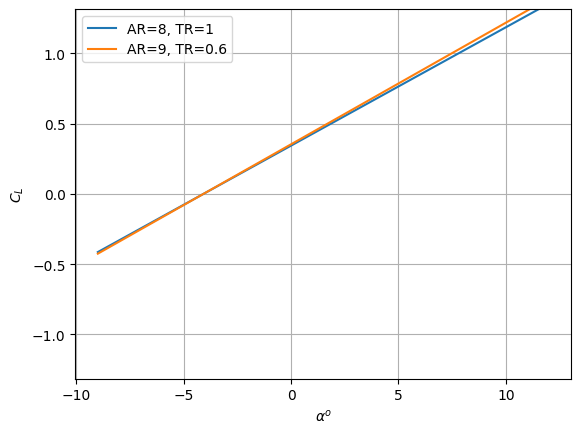

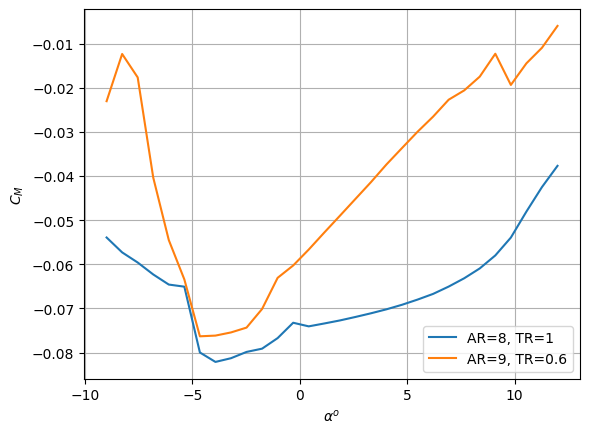

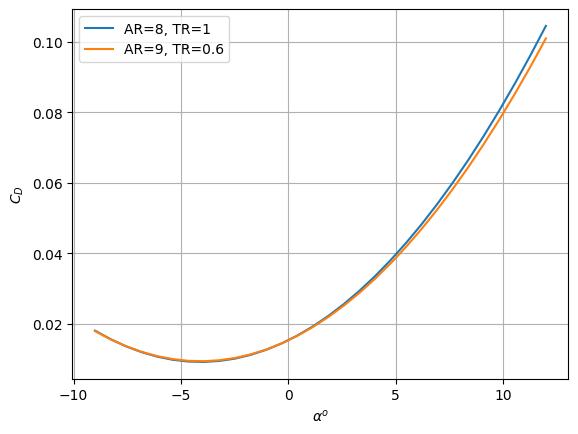

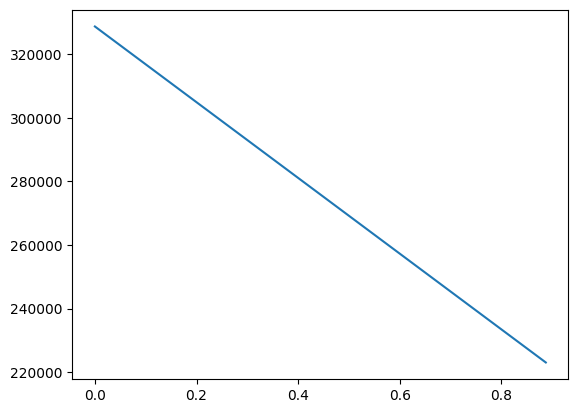

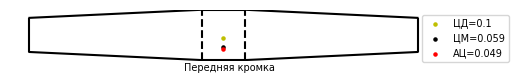

In [ ]:
AspectRatioArray = [4,5,6,7,8,9,10,11,12]

TaperRatioArray = [0.15, 0.3, 0.45, 0.6, 0.75, 0.9, 1]

AlphaArray = np.linspace(-9, 12, 30)

CD0wing = []
CDiwing = []
CLwing = []
Cmwing = []

CD0wingT = []
CDiwingT = []
CLwingT = []
CmwingT = []

for alpha in AlphaArray:
    S = 0.35
    WingAirfoil = "SD7032"
    TR = 1
    AR = 8
    cr = 0.23
    cf = 0.3
    iw = 0 # угол установки крыла
    etai = 0.5 # координата начала элеронов в ед полуразмаха
    etae = 1 # координата конца элеронов в ед полуразмаха
    WingData = (WingAirfoil, S, TR, AR, cr, cf, etai, etae, iw)

    type = 'V'
    TailAirfoil = 'NACA0008_300'
    Vht = 0.6
    Vvt = 0.04
    Lt = 0.8
    itail = 0 # Угол установки хвостового оперения
    cf = 0.3
    etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
    etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
    TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)

    pl = UAV(3.5, 21, 0.25, WingData, 0.2, 0.7, Tail=TailData, SweepQuart=False)
    #print(pl.b, pl.cr, pl.S)
    CD0wing.append(pl.GetTotalDragCoefficient(AOA=alpha, deflec=0, distr="Wing")[0])
    CDiwing.append(pl.GetTotalDragCoefficient(AOA=alpha, deflec=0, distr="Wing")[1])
    Cmwing.append(pl.GetCm(AOA=alpha, deflec=0, distr=True)[0])
    CLwing.append(pl.GetTotalLiftCoefficient(AOA=alpha, deflecW=0, deflecT=0, distr="Wing"))

for alpha in AlphaArray:
    S = 0.35
    WingAirfoil = "SD7032"
    TRT = 0.6
    ART = 9
    cr = 0.23
    cf = 0.3
    iw = 0 # угол установки крыла
    etai = 0.5 # координата начала элеронов в ед полуразмаха
    etae = 1 # координата конца элеронов в ед полуразмаха
    WingData = (WingAirfoil, S, TRT, ART, cr, cf, etai, etae, iw)

    type = 'V'
    TailAirfoil = 'NACA0008_300'
    Vht = 0.6
    Vvt = 0.04
    Lt = 0.8
    itail = 0 # Угол установки хвостового оперения
    cf = 0.3
    etaitail = 0.1 # координата начала руля высоты в ед полуразмаха
    etaetail = 0.9 # координата конца руля высоты в ед полуразмаха
    TailData = (type, TailAirfoil, Vht, Vvt, Lt, cf, etaitail, etaetail, itail)

    pl = UAV(3.5, 21, 0.3, WingData, 0.2, 0.7, TailData, cr=0.23, SweepQuart=True)
    print(pl.b, pl.cr, pl.S)
    CD0wingT.append(pl.GetTotalDragCoefficient(AOA=alpha, deflec=0, distr="Wing")[0])
    CDiwingT.append(pl.GetTotalDragCoefficient(AOA=alpha, deflec=0, distr="Wing")[1])
    CmwingT.append(pl.GetCm(AOA=alpha, deflec=0, distr=True)[0])
    CLwingT.append(pl.GetTotalLiftCoefficient(AOA=alpha, deflecW=0, deflecT=0, distr="Wing"))

plt.figure()
plt.plot(AlphaArray, CLwing, label = "AR={}, TR={}".format(AR, TR))
plt.plot(AlphaArray, CLwingT, label = "AR={}, TR={}".format(ART, pl.TRT))
plt.xlabel(r"$\alpha^{o}$")
plt.ylabel(r"$C_{L}$")
plt.legend()
plt.grid()
plt.ylim(-pl.GetCLmax(), pl.GetCLmax())

plt.figure()
plt.plot(AlphaArray, Cmwing, label = "AR={}, TR={}".format(AR, TR))
plt.plot(AlphaArray, CmwingT, label = "AR={}, TR={}".format(ART, pl.TRT))
plt.legend()
plt.xlabel(r"$\alpha^{o}$")
plt.ylabel(r"$C_{M}$")
plt.grid()

plt.figure()
plt.plot(AlphaArray, np.array(CD0wing) + np.array(CDiwing), label = "AR={}, TR={}".format(AR, TR))
plt.plot(AlphaArray, np.array(CD0wingT) + np.array(CDiwingT), label = "AR={}, TR={}".format(ART, pl.TRT))
plt.legend()
plt.xlabel(r"$\alpha^{o}$")
plt.ylabel(r"$C_{D}$")
plt.grid()

plt.figure()
plt.plot(pl.GetReynoldsSpanDistribution()[0], pl.GetReynoldsSpanDistribution()[1])

pl.PlotWing()
# plt.figure()
# print(pl.GetReynolds(type="LocalW", x=0))
# plt.plot(pl.GetAirfoilWingData(y=pl.b/4)[0], pl.GetAirfoilWingData(y=pl.b/4)[1](pl.GetAirfoilWingData(y=pl.b/4)[0]))

### Модель коэффициента подъемной силы
$$C_L = C_{L_{0}} + C_{L_{\alpha}}\alpha + C_{L_{\delta_{e}}}\delta_{e} + C_{L_{q}}\frac{c}{2v_a}q$$

#### Наклон кривой коэффициента подъемной силы $C_{L_{\alpha}}$
![.](LiftCurveSlope.jpg)
![.](LiftCurveSlopeRaymer.jpg)

#### Угол атаки нулевой подъемной силы

![.](ZeroLiftCoef.jpg)

#### Коэффициент эффективности Освальда

![.](OsvaldEfficiency.jpg)

#### Требуемый коэффициент подъемной силы при заданной скорости полета и массе ЛА

![.](CruiseLiftCoefficient.jpg)


#### Приращение коэф подъемной силы профиля при отклонении управляющих поверхностей
![.](PlainFlapAirfoilLiftIncrement.png)

#### Приращение коэф подъемной силы крыла при отклонении управляющих поверхностей
![.](PlainFlapWingLiftIncrement.png)

### Модель коэффициента лобового сопротивления
$$C_D = C_{D_{0}} + C_{D{\alpha}}\alpha + C_{D_{\delta_{e}}}\delta_{e} + C_{D_{q}}\frac{c}{2v_a}q$$
Для более точной оценки лобового сопротивления в зависимости от угла атаки и геометрических характеристик ЛА используем дополненную квадратичную модель коэффициента лобового сопроивления
$$C_{D_{0}} + C_{D_{\alpha}}\alpha = C_{D}(\alpha) = C_{D_{0}} + C_{D_{i}} = C_{D_{0}} + \frac{(C_{L}(\alpha) - C_{LmD})^{2}}{\pi e AR}$$
где $C_{D_{0}}$ - паразитное сопроивление, $C_{D_{i}}$ - индуцированное сопротивление засчет подъемной силы, $e$ - коэффициент эффективности Освальда
$$C_{D_{\alpha}} = \frac{\partial C_{D}(\alpha)}{\partial \alpha} = \frac{2}{\pi e AR}(C_{L_{0}} + C_{L_{\alpha}}\alpha - C_{LmD})C_{L_{\alpha}}$$
$$C_{D_{0}} = (C_{D_{add}} + \frac{1}{S}(\sum_{i}(C_{f_{i}} \times FF_{i} \times S_{wet_{i}} \times IF_{i})))k_{crud}$$
где $C_{f}$ - коэффициент сил трения

$FF (Form factor)$ - множитель, учитывающий форму обтекаемого тела (крыла, фюзеляжа)

$S_{wet}$ - полная площадь поверхности тела, которая обтекается воздухом

$IF (Interference factor)$ - множитель, учитывающий взаимное расположение и влияние элементов на друг друга 

$C_{D_{add}}$ - дополнительный коэффициент сопротивления за счет элементов конструкции, не являющихся крылом или фюзеляжем, например, подвесных конструкций на крыле

$k_{crud}$ (Cumulative Result of Undesirable
 Drag) - множитель, учитывающий неидеальность конструкции, отличие расчетных форм поверхностей от действительных

Суммирирование производится по всем рассматриваемым элементам: крыло, фюзеляж, хвостовое оперение

#### Оценка паразитного сопротивления $C_{D_{0}}$
![.](CdminEstimationAlgorithm.jpg)

#### Фактор взаимодействия элементов конструкции между собой
![.](InterferenceFactor.jpg)

#### Неровность поверхности материала

Если понимать данные в таблице, как характерный размер неровностей на поверхности материала, то для детали изготовленной на 3Д принере-  ?
![.](SurfaceRoughness.jpg)

#### CRUD $k_{crud}$
![.](CRUDfactor.jpg)

#### Коэффициент силы трения для профиля крыла, хвостового оперения
![.](SkinFrictionCoef.jpg)

#### Оценка $C_{D_{\delta_{e}}}$
![.](CLDdeltaEstimation.png)

## Модель коэффициента момента тангажа
$$C_{m} = C_{m_{0}} + C_{m_{\alpha}}\alpha + C_{m_{\delta_{e}}}\delta_{e} + C_{m_{q}}\frac{c}{2V_{a}}q$$

#### Общий вид ЛА и обозначений для статической устойчивости
![.](GenerPlaneView.png)

#### Коэффициент момента тангажа для крыла
![.](WingPitchingMoment.png)

![.](WingZeroPitchingMomentCoeff.png)